In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath('..'))

from simulator.loader import MarketDataLoader
from simulator.hmm import HybridJumpsHMM

# 1. Fetch historical SPY data
ticker = "SPY"
loader = MarketDataLoader(tickers=[ticker], start_date="2014-01-01", end_date="2024-01-01")
market_data = loader.fetch_data()
returns = market_data[ticker].dropna()

# 2. Fit HMM model
model = HybridJumpsHMM(n_states=100)
model.fit(returns)

# Optimal parameters from main.py
best_eps = 0.0005
best_lambd = 130

# 3. Generate 10 synthetic paths to show the ensemble envelope
n_steps = len(returns)
n_ensemble_paths = 10
sim_paths_returns = []

np.random.seed(42)
for _ in range(n_ensemble_paths):
    states = model.simulate_states(n_steps=n_steps, epsilon=best_eps, lambd=best_lambd)
    path_returns = model.decode_states(states)
    sim_paths_returns.append(path_returns)

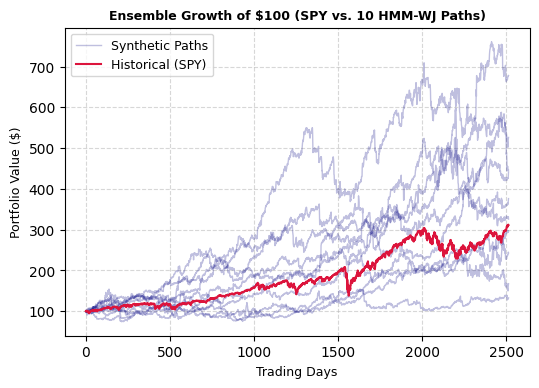

In [2]:
# 1. Calculate historical cumulative growth of $100
hist_cum = 100 * np.cumprod(1 + returns.to_numpy())

plt.figure(figsize=(6, 4))

# 2. Plot 10 synthetic ensemble paths in thin light navy
for i, path_ret in enumerate(sim_paths_returns):
    sim_cum = 100 * np.cumprod(1 + path_ret)
    label = "Synthetic Paths" if i == 0 else ""
    plt.plot(sim_cum, color="navy", alpha=0.25, linewidth=1, label=label)

# 3. Plot historical SPY in bold crimson
plt.plot(hist_cum, color="crimson", linewidth=1.5, label=f"Historical ({ticker})")

plt.title(f"Ensemble Growth of $100 ({ticker} vs. 10 HMM-WJ Paths)", fontsize=9, fontweight="bold")
plt.xlabel("Trading Days", fontsize=9)
plt.ylabel("Portfolio Value ($)", fontsize=9)
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Interpretation: Shows that the historical SPY growth path sits comfortably within the realistic envelope of 10 simulated HMM-WJ market trajectories.

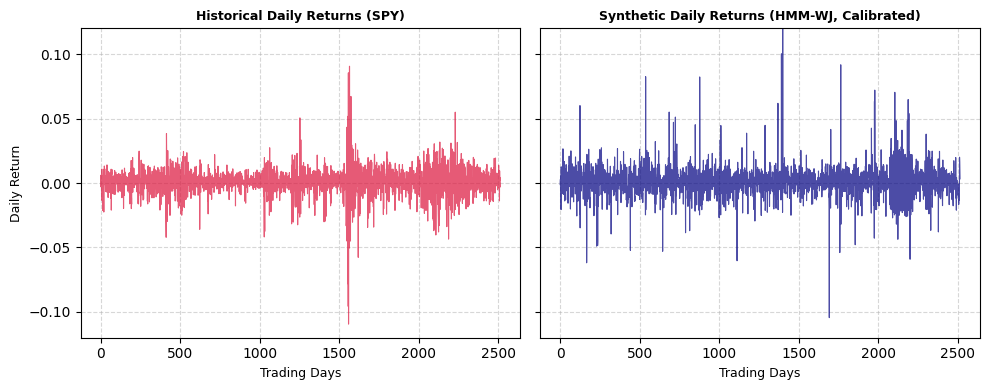

In [3]:
# Create side-by-side subplots for daily returns comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# 1. Historical SPY Daily Returns
axes[0].plot(returns.to_numpy(), color="crimson", alpha=0.7, linewidth=0.8)
axes[0].set_title(f"Historical Daily Returns ({ticker})", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Trading Days", fontsize=9)
axes[0].set_ylabel("Daily Return", fontsize=9)
axes[0].set_ylim(-0.12, 0.12)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Synthetic HMM-WJ Daily Returns (Path 0 from calibrated ensemble)
axes[1].plot(sim_paths_returns[0], color="navy", alpha=0.7, linewidth=0.8)
axes[1].set_title("Synthetic Daily Returns (HMM-WJ, Calibrated)", fontsize=9, fontweight="bold")
axes[1].set_xlabel("Trading Days", fontsize=9)
axes[1].set_ylim(-0.12, 0.12)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Interpretation: Compares daily return wiggles, showing that synthetic returns reproduce calm regimes alongside volatility crash clusters.

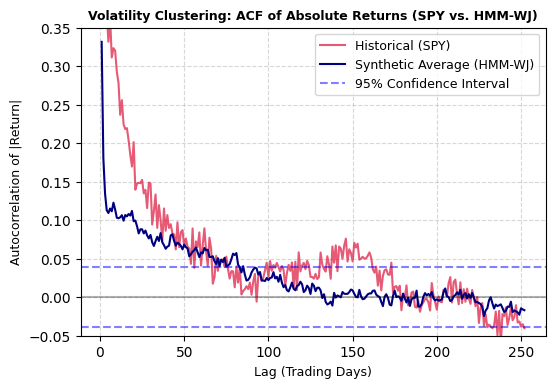

In [4]:
from statsmodels.tsa.stattools import acf

# 1. Compute ACF of absolute historical returns (252 lags)
lags = 252
acf_hist_abs = acf(np.abs(returns.to_numpy()), nlags=lags, fft=True)[1:]

# 2. Compute average ACF of absolute returns across all 10 synthetic ensemble paths
acf_sim_paths = []
for path_ret in sim_paths_returns:
    path_acf = acf(np.abs(path_ret), nlags=lags, fft=True)[1:]
    acf_sim_paths.append(path_acf)

acf_sim_avg = np.mean(acf_sim_paths, axis=0)

# 3. 95% Confidence Interval bound
conf_bound = 1.96 / np.sqrt(len(returns))

# 4. Plot ACF Comparison (Paper's Figure 3b)
plt.figure(figsize=(6, 4))
plt.plot(range(1, lags + 1), acf_hist_abs, color="crimson", alpha=0.7, label=f"Historical ({ticker})")
plt.plot(range(1, lags + 1), acf_sim_avg, color="navy", linewidth=1.5, label="Synthetic Average (HMM-WJ)")

plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.axhline(y=conf_bound, color="blue", linestyle="--", alpha=0.5, label="95% Confidence Interval")
plt.axhline(y=-conf_bound, color="blue", linestyle="--", alpha=0.5)

plt.title(f"Volatility Clustering: ACF of Absolute Returns ({ticker} vs. HMM-WJ)", fontsize=9, fontweight="bold")
plt.xlabel("Lag (Trading Days)", fontsize=9)
plt.ylabel("Autocorrelation of |Return|", fontsize=9)
plt.ylim(-0.05, 0.35)
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Interpretation: Demonstrates that HMM-WJ elevates the absolute return ACF into the 0.06-0.08 range across 252 lags, partially capturing historical volatility clustering.